In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
from src.features.preprocessing import build_preprocessor

In [4]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "telco_churn_clean.csv"
)

MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "split_manifest.csv"
)

SELECTED_MODEL_PATH = (
    PROJECT_ROOT
    / "reports"
    / "selected_model.json"
)

THRESHOLD_PATH = (
    PROJECT_ROOT
    / "reports"
    / "decision_threshold.json"
)

df = pd.read_csv(DATA_PATH)
manifest = pd.read_csv(MANIFEST_PATH)

with open(SELECTED_MODEL_PATH, "r") as file:
    selected_info = json.load(file)

with open(THRESHOLD_PATH, "r") as file:
    threshold_info = json.load(file)

print("Selected model:",
      selected_info["model_family"])

print(
    "Decision threshold:",
    round(
        threshold_info["selected_threshold"],
        4
    )
)

Selected model: XGBoost
Decision threshold: 0.4826


In [5]:
data = df.merge(
    manifest[["customerID", "split"]],
    on="customerID",
    how="left",
    validate="one_to_one"
)

train_data = data[
    data["split"] == "train"
].copy()

test_data = data[
    data["split"] == "test"
].copy()

DROP_COLUMNS = [
    "customerID",
    "Churn",
    "split",
]

X_train = train_data.drop(
    columns=DROP_COLUMNS
)

X_test = test_data.drop(
    columns=DROP_COLUMNS
)

y_train = train_data["Churn"].map({
    "No": 0,
    "Yes": 1,
})

y_test = test_data["Churn"].map({
    "No": 0,
    "Yes": 1,
})

id_test = test_data["customerID"].copy()

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (5634, 19)
Test : (1409, 19)


In [6]:
selected_family = selected_info[
    "model_family"
]

selected_params = selected_info[
    "best_parameters"
]


def build_final_pipeline(
    family,
    parameters
):

    if family == "Logistic Regression":

        classifier = LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=42,
        )

    elif family == "Random Forest":

        classifier = RandomForestClassifier(
            random_state=42,
            n_jobs=1,
        )

    elif family == "XGBoost":

        classifier = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=1,
        )

    else:
        raise ValueError(
            f"Unknown model: {family}"
        )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                build_preprocessor()
            ),
            (
                "classifier",
                classifier
            ),
        ]
    )

    pipeline.set_params(
        **parameters
    )

    return pipeline

In [7]:
# full train data model train
final_pipeline = build_final_pipeline(
    selected_family,
    selected_params
)

final_pipeline.fit(
    X_train,
    y_train
)

print("Final pipeline fitted.")

Final pipeline fitted.


In [8]:
test_probabilities = (
    final_pipeline
    .predict_proba(X_test)[:, 1]
)

print(
    "Minimum probability:",
    test_probabilities.min()
)

print(
    "Maximum probability:",
    test_probabilities.max()
)

Minimum probability: 0.012400895
Maximum probability: 0.93437773


In [9]:
perm_result = permutation_importance(
    estimator=final_pipeline,
    X=X_test,
    y=y_test,

    scoring="average_precision",

    n_repeats=20,

    random_state=42,

    n_jobs=-1,
)

In [10]:
# importance table
permutation_df = pd.DataFrame({
    "Feature": X_test.columns,

    "Importance Mean":
        perm_result.importances_mean,

    "Importance Std":
        perm_result.importances_std,
})

permutation_df = (
    permutation_df
    .sort_values(
        "Importance Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_df.round(4)

,Feature,Importance Mean,Importance Std
0,tenure,0.1350,0.0153
1,Contract,0.0880,0.0188
2,InternetService,0.0246,0.0098
3,OnlineSecurity,0.0143,0.0097
4,TechSupport,0.0105,0.0064
5,MonthlyCharges,0.0104,0.0071
6,TotalCharges,0.0082,0.0038
7,PaperlessBilling,0.0046,0.0053
8,PaymentMethod,0.0020,0.0065
9,OnlineBackup,0.0017,0.0028


In [11]:
# top 10 features
permutation_df.head(10)

,Feature,Importance Mean,Importance Std
0,tenure,0.134958,0.015348
1,Contract,0.087978,0.018787
2,InternetService,0.024617,0.009822
3,OnlineSecurity,0.014250,0.009710
4,TechSupport,0.010505,0.006382
5,MonthlyCharges,0.010396,0.007122
6,TotalCharges,0.008199,0.003829
7,PaperlessBilling,0.004559,0.005304
8,PaymentMethod,0.001973,0.006549
9,OnlineBackup,0.001733,0.002785


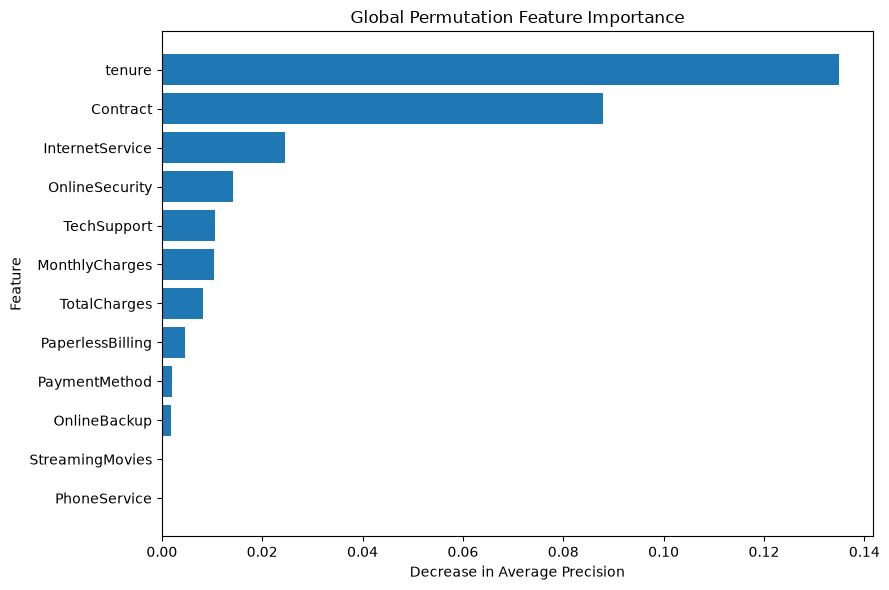

In [12]:
# Global feature importance graph
top_features = (
    permutation_df
    .head(12)
    .sort_values(
        "Importance Mean"
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance Mean"]
)

plt.xlabel(
    "Decrease in Average Precision"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Global Permutation Feature Importance"
)

plt.tight_layout()

FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    FIGURE_DIR
    / "global_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
#importance save
PERMUTATION_PATH = (
    PROJECT_ROOT
    / "reports"
    / "permutation_importance.csv"
)

permutation_df.to_csv(
    PERMUTATION_PATH,
    index=False
)

In [14]:
#fitted process + classifer
fitted_preprocessor = (
    final_pipeline
    .named_steps["preprocessor"]
)

fitted_classifier = (
    final_pipeline
    .named_steps["classifier"]
)

In [15]:
#train and test transformation
X_train_transformed = (
    fitted_preprocessor
    .transform(X_train)
)

X_test_transformed = (
    fitted_preprocessor
    .transform(X_test)
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print(
    X_train_transformed.shape
)

print(
    X_test_transformed.shape
)

print(
    "Feature names:",
    len(feature_names)
)

(5634, 46)
(1409, 46)
Feature names: 46


In [16]:
#SHAP transform sample
rng = np.random.RandomState(42)

background_size = min(
    200,
    len(X_train_transformed)
)

background_indices = rng.choice(
    len(X_train_transformed),
    size=background_size,
    replace=False
)

background_data = (
    X_train_transformed[
        background_indices
    ]
)

In [20]:
# shape explain
explainer = shap.TreeExplainer(
    fitted_classifier,
    feature_perturbation="tree_path_dependent",
    feature_names=feature_names,
)

print("SHAP TreeExplainer created.")

SHAP TreeExplainer created.


In [22]:
EXPLAIN_SIZE = min(
    300,
    len(X_test_transformed)
)

X_explain = X_test_transformed[
    :EXPLAIN_SIZE
]

shap_values = explainer(
    X_explain,
    check_additivity=False
)

print(
    "SHAP values shape:",
    shap_values.values.shape
)

SHAP values shape: (300, 46)


In [23]:
if shap_values.values.ndim == 3:

    shap_positive = (
        shap_values[:, :, 1]
    )

else:

    shap_positive = shap_values


print(
    "SHAP shape:",
    shap_positive.values.shape
)

SHAP shape: (300, 46)


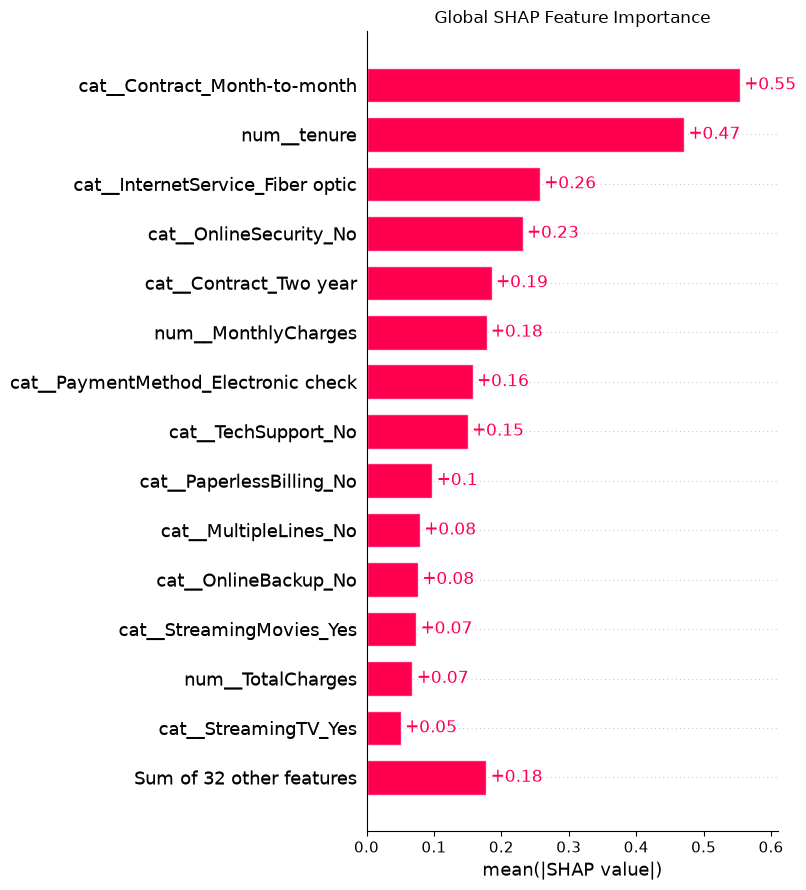

In [24]:
#shap global ploat bar
shap.plots.bar(
    shap_positive,
    max_display=15,
    show=False
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "global_shap_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
#numirical shap importance table
mean_abs_shap = np.abs(
    shap_positive.values
).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP":
        mean_abs_shap,
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance_df.head(15)

,Feature,Mean Absolute SHAP
0,cat__Contract_Month-to-month,0.553689
1,num__tenure,0.470914
2,cat__InternetService_Fiber optic,0.257077
3,cat__OnlineSecurity_No,0.231482
4,cat__Contract_Two year,0.185652
5,num__MonthlyCharges,0.177966
6,cat__PaymentMethod_Electronic check,0.157446
7,cat__TechSupport_No,0.149939
8,cat__PaperlessBilling_No,0.097697
9,cat__MultipleLines_No,0.079155


In [26]:
#save
shap_importance_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "shap_global_importance.csv",
    index=False
)

In [27]:
#highest risk identify customer
highest_risk_position = int(
    np.argmax(test_probabilities)
)

highest_risk_probability = (
    test_probabilities[
        highest_risk_position
    ]
)

highest_risk_customer = (
    id_test.iloc[
        highest_risk_position
    ]
)

selected_threshold = float(
    threshold_info[
        "selected_threshold"
    ]
)

highest_risk_prediction = int(
    highest_risk_probability
    >= selected_threshold
)

print(
    "Customer ID:",
    highest_risk_customer
)

print(
    "Churn probability:",
    round(
        highest_risk_probability,
        4
    )
)

print(
    "Decision threshold:",
    round(
        selected_threshold,
        4
    )
)

print(
    "Predicted class:",
    highest_risk_prediction
)

Customer ID: 5178-LMXOP
Churn probability: 0.9344
Decision threshold: 0.4826
Predicted class: 1


In [28]:
#customer raw information
X_test.iloc[
    [highest_risk_position]
].T

,3380
gender,Male
SeniorCitizen,1
Partner,Yes
Dependents,No
tenure,1
PhoneService,Yes
MultipleLines,Yes
InternetService,Fiber optic
OnlineSecurity,No
OnlineBackup,No


In [29]:
#customer and shape explanation
customer_transformed = (
    X_test_transformed[
        highest_risk_position:
        highest_risk_position + 1
    ]
)

customer_shap = explainer(
    customer_transformed
)

if customer_shap.values.ndim == 3:
    customer_shap_positive = (
        customer_shap[:, :, 1]
    )
else:
    customer_shap_positive = (
        customer_shap
    )

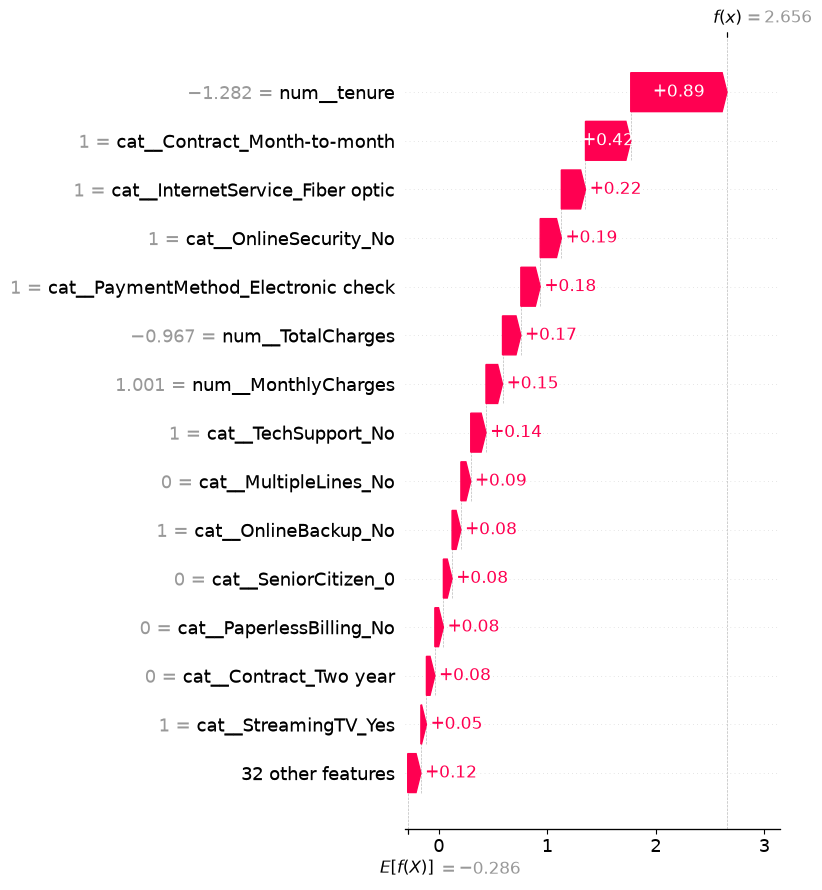

In [30]:
#waterfall ploat
shap.plots.waterfall(
    customer_shap_positive[0],
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "high_risk_customer_shap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
#local explanation table
local_explanation = pd.DataFrame({
    "Feature":
        feature_names,

    "Transformed Value":
        customer_transformed[0],

    "SHAP Value":
        customer_shap_positive
        .values[0],
})

In [32]:
local_explanation[
    "Absolute SHAP"
] = np.abs(
    local_explanation[
        "SHAP Value"
    ]
)

local_explanation = (
    local_explanation
    .sort_values(
        "Absolute SHAP",
        ascending=False
    )
)

local_explanation.head(15)

,Feature,Transformed Value,SHAP Value,Absolute SHAP
0,num__tenure,-1.281624,0.886850,0.886850
37,cat__Contract_Month-to-month,1.000000,0.417083,0.417083
17,cat__InternetService_Fiber optic,1.000000,0.222491,0.222491
19,cat__OnlineSecurity_No,1.000000,0.194822,0.194822
44,cat__PaymentMethod_Electronic check,1.000000,0.178340,0.178340
2,num__TotalCharges,-0.967193,0.169037,0.169037
1,num__MonthlyCharges,1.001148,0.152208,0.152208
28,cat__TechSupport_No,1.000000,0.140437,0.140437
13,cat__MultipleLines_No,0.000000,0.090674,0.090674
22,cat__OnlineBackup_No,1.000000,0.081300,0.081300


In [33]:
#save
LOCAL_PATH = (
    PROJECT_ROOT
    / "reports"
    / "high_risk_customer_explanation.csv"
)

local_explanation.to_csv(
    LOCAL_PATH,
    index=False
)

In [34]:
#Human-readable top churn drivers
positive_drivers = (
    local_explanation[
        local_explanation[
            "SHAP Value"
        ] > 0
    ]
    .head(5)
)

negative_drivers = (
    local_explanation[
        local_explanation[
            "SHAP Value"
        ] < 0
    ]
    .head(5)
)

print("TOP CHURN-RISK DRIVERS")
print(
    positive_drivers[
        ["Feature", "SHAP Value"]
    ]
)

print(
    "\nTOP RETENTION DRIVERS"
)

print(
    negative_drivers[
        ["Feature", "SHAP Value"]
    ]
)

TOP CHURN-RISK DRIVERS
                                Feature  SHAP Value
0                           num__tenure    0.886850
37         cat__Contract_Month-to-month    0.417083
17     cat__InternetService_Fiber optic    0.222491
19               cat__OnlineSecurity_No    0.194822
44  cat__PaymentMethod_Electronic check    0.178340

TOP RETENTION DRIVERS
                      Feature  SHAP Value
38     cat__Contract_One year   -0.011945
11       cat__PhoneService_No   -0.003294
27  cat__DeviceProtection_Yes   -0.001855
21    cat__OnlineSecurity_Yes   -0.000852
12      cat__PhoneService_Yes   -0.000062


In [35]:
#explanatin summary save
EXPLANATION_SUMMARY_PATH = (
    PROJECT_ROOT
    / "reports"
    / "explainability_summary.json"
)

summary = {
    "model_family":
        selected_family,

    "decision_threshold":
        selected_threshold,

    "explained_customer":
        str(
            highest_risk_customer
        ),

    "churn_probability":
        float(
            highest_risk_probability
        ),

    "predicted_class":
        int(
            highest_risk_prediction
        ),

    "permutation_metric":
        "average_precision",

    "shap_sample_size":
        EXPLAIN_SIZE,
}

with open(
    EXPLANATION_SUMMARY_PATH,
    "w"
) as file:

    json.dump(
        summary,
        file,
        indent=4
    )

In [36]:
#valadition
assert len(
    permutation_df
) == 19

assert len(
    feature_names
) == 46

assert (
    shap_positive.values.shape[1]
    == 46
)

assert (
    0
    <= highest_risk_probability
    <= 1
)

print(
    "Explainability validation passed."
)

Explainability validation passed.
